In [2]:
daily_pnl = merged.groupby(['account','date'])['closed pnl'].sum().reset_index()
daily_pnl.rename(columns={'closed pnl':'daily_pnl'}, inplace=True)

In [3]:
trade_count = merged.groupby(['account','date']).size().reset_index(name='trade_count')

In [5]:
merged['win'] = merged['closed pnl'] > 0

win_rate = merged.groupby(['account','date'])['win'].mean().reset_index()

In [6]:
avg_position = merged.groupby(['account','date'])['start position'].mean().reset_index()

In [7]:
daily_metrics = daily_pnl.merge(trade_count, on=['account','date'])
daily_metrics = daily_metrics.merge(win_rate, on=['account','date'])
daily_metrics = daily_metrics.merge(avg_position, on=['account','date'])

daily_metrics = daily_metrics.merge(
    merged[['date','classification']].drop_duplicates(),
    on='date'
)

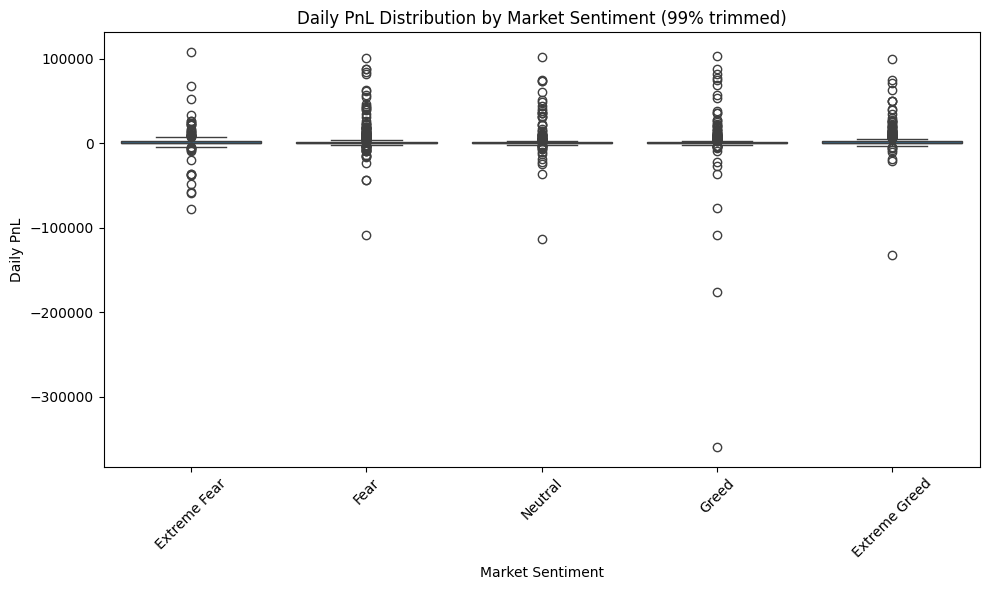

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))


clip_limit = daily_metrics['daily_pnl'].quantile(0.99)
filtered = daily_metrics[daily_metrics['daily_pnl'] < clip_limit]

order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

sns.boxplot(
    data=filtered,
    x='classification',
    y='daily_pnl',
    order=order
)

plt.title("Daily PnL Distribution by Market Sentiment (99% trimmed)")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

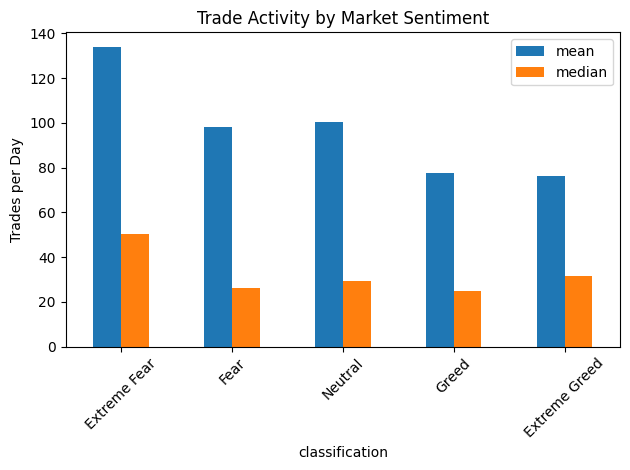

In [14]:
plt.figure(figsize=(10,6))

freq_stats = daily_metrics.groupby('classification')['trade_count'].agg(['mean','median'])
freq_stats = freq_stats.loc[order]

freq_stats.plot(kind='bar')

plt.title("Trade Activity by Market Sentiment")
plt.ylabel("Trades per Day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

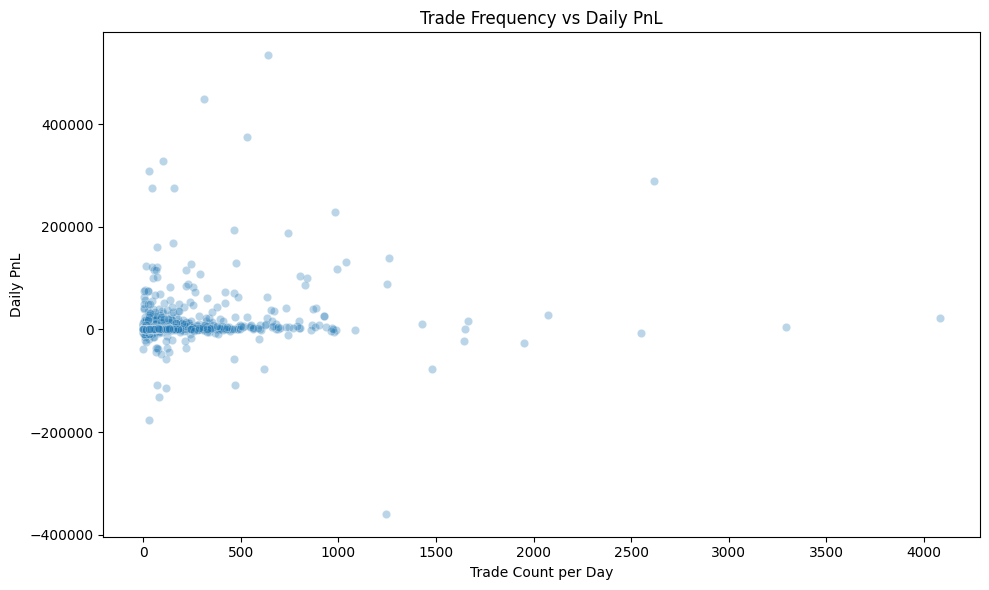

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=daily_metrics,
    x='trade_count',
    y='daily_pnl',
    alpha=0.3
)

plt.title("Trade Frequency vs Daily PnL")
plt.xlabel("Trade Count per Day")
plt.ylabel("Daily PnL")
plt.tight_layout()
plt.show()

In [16]:
# Sort properly
daily_metrics = daily_metrics.sort_values(['account','date'])

# Shift next-day pnl
daily_metrics['next_day_pnl'] = daily_metrics.groupby('account')['daily_pnl'].shift(-1)

# Create binary target
daily_metrics['next_day_profit'] = (daily_metrics['next_day_pnl'] > 0).astype(int)

# Drop last rows (no next day)
model_df = daily_metrics.dropna(subset=['next_day_profit'])

In [17]:
model_df['classification'] = model_df['classification'].astype('category')
model_df['sentiment_code'] = model_df['classification'].cat.codes

In [18]:
features = model_df[['daily_pnl','trade_count','win','start position','sentiment_code']]
target = model_df['next_day_profit']

In [19]:
features = features.fillna(0)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.6076759061833689
ROC AUC: 0.5106382978723405
              precision    recall  f1-score   support

           0       1.00      0.02      0.04       188
           1       0.60      1.00      0.75       281

    accuracy                           0.61       469
   macro avg       0.80      0.51      0.40       469
weighted avg       0.76      0.61      0.47       469



In [27]:
coefficients = pd.Series(
    log_model.coef_[0],
    index=features.columns
).sort_values()

print(coefficients)

daily_pnl        -0.075813
sentiment_code   -0.025308
start position    0.096742
win               0.315297
trade_count       0.379889
dtype: float64
